<div style="background-color:#e6f2ff; padding:20px; border-radius:10px;">
<img style="float:left; margin-right:20px;" src='Figures/alinco.png' width="120"/>
<h1 style="color:#000047;">Actividad 2: PipelineTokenizacionNormalizaciónStemmerLematizacion</h1>
<br style="clear:both"/>
</div>

<div style="border-left:4px solid #000047; padding:10px; margin-top:10px; background:#f5f5f5;">
<b>Objetivo:</b> Crear una clase con un pipeline que tokenice, elimine stopwords, aplique stemming y lematizacion, y mida el impacto en el vocabulario.
</div>

<div style="margin-top:10px;">
<b>Instrucciones generales:</b>
<ul>
<li>Crea tu propia clase para preprocesamiento de texto considerando Normalización de texto, Stemming/Lematización y Tokenización para un corpus en inglés y español</li>
<li>Procesa el corpus provisto de 4 textos en inglés y procesa el corpus de noticias en español</li>
<li>Calcula la reduccion de vocabulario en cada etapa</li>
<li>Visualiza los resultados con matplotlib</li>

</ul>
</div>

In [11]:
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import PorterStemmer, SnowballStemmer, WordNetLemmatizer
from nltk.corpus import wordnet
import string
import pandas as pd
class NLPTextCleaningPipeline:
    def __init__(self):
        pass


In [12]:
# Corpus simple en inglés
corpus_en = [
    {'Documento':'text_1','texto':'Natural language processing systems are becoming increasingly sophisticated.'},
    {'Documento':'text_2','texto':'Deep learning models have revolutionized text classification and generation tasks.'},
    {'Documento':'text_3','texto':'Tokenization is the fundamental first step in any NLP preprocessing pipeline.'},
    {'Documento':'text_4','texto':'Researchers are studying computational approaches to human language understanding.'},
]
df_corpus_en = pd.DataFrame(corpus_en)
df_corpus_en

,Documento,texto
0,text_1,Natural language processing systems are becomi...
1,text_2,Deep learning models have revolutionized text ...
2,text_3,Tokenization is the fundamental first step in ...
3,text_4,Researchers are studying computational approac...


In [13]:
#  Corpus de noticias en español
noticias = [
    {"categoria": "tecnología", "texto": "Apple presentó su nuevo chip M4 con IA integrada. La presentación fue en WWDC 2026 #Apple #M4"},
    {"categoria": "tecnología", "texto": "Google lanzó Gemini Ultra, su modelo más poderoso. Supera a GPT-4 en benchmarks https://blog.google.com"},
    {"categoria": "tecnología", "texto": "OpenAI anunció GPT-5 con capacidades multimodales avanzadas @OpenAI"},
    {"categoria": "economía",   "texto": "El peso mexicano se fortalece frente al dólar: $17.50 por USD en mercados internacionales"},
    {"categoria": "economía",   "texto": "La inflación en México cayó al 3.2% en abril 2026, según INEGI #Economia"},
    {"categoria": "economía",   "texto": "Inversión extranjera directa creció 15% en el primer trimestre del año"},
    {"categoria": "ciencia",    "texto": "Científicos descubrieron nueva especie de dinosaurio en Argentina #Paleontología"},
    {"categoria": "ciencia",    "texto": "Investigadores del MIT desarrollaron batería de estado sólido con carga en 5 minutos"},
    {"categoria": "ciencia",    "texto": "La NASA confirmó presencia de agua en la luna sur mediante misión Artemis https://nasa.gov"},
    {"categoria": "salud",      "texto": "Nuevo tratamiento contra el cáncer de páncreas muestra 80% de efectividad en ensayos clínicos"},
    {"categoria": "salud",      "texto": "OMS alerta sobre aumento de casos de resistencia a antibióticos en Latinoamérica #Salud"},
    {"categoria": "salud",      "texto": "Vacuna contra el dengue disponible en farmacias de México a partir de junio 2026"},
]

df_noticias_esp = pd.DataFrame(noticias)
df_noticias_esp

,categoria,texto
0,tecnología,Apple presentó su nuevo chip M4 con IA integra...
1,tecnología,"Google lanzó Gemini Ultra, su modelo más poder..."
2,tecnología,OpenAI anunció GPT-5 con capacidades multimoda...
3,economía,El peso mexicano se fortalece frente al dólar:...
4,economía,La inflación en México cayó al 3.2% en abril 2...
5,economía,Inversión extranjera directa creció 15% en el ...
6,ciencia,Científicos descubrieron nueva especie de dino...
7,ciencia,Investigadores del MIT desarrollaron batería d...
8,ciencia,La NASA confirmó presencia de agua en la luna ...
9,salud,Nuevo tratamiento contra el cáncer de páncreas...


In [14]:
import nltk
import re
import matplotlib.pyplot as plt
from nltk.corpus import stopwords

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

class NLPTextCleaningPipeline:

    def __init__(self, language='english'):
        self.language = language

        if language == 'english':
            self.stop_words = set(stopwords.words('english'))
            self.stemmer = PorterStemmer()
        else:
            self.stop_words = set(stopwords.words('spanish'))
            self.stemmer = SnowballStemmer('spanish')

        self.lemmatizer = WordNetLemmatizer()

    def normalize(self, text):
        text = text.lower()
        text = re.sub(r"http\S+", "", text)
        text = re.sub(r"[@#]\w+", "", text)
        text = re.sub(r"[^a-záéíóúñü\s]", " ", text)
        return text

    def tokenize(self, text):
        return word_tokenize(text)

    def remove_stopwords(self, tokens):
        return [t for t in tokens if t not in self.stop_words]

    def stem(self, tokens):
        return [self.stemmer.stem(t) for t in tokens]

    def lemmatize(self, tokens):
        if self.language == 'english':
            return [self.lemmatizer.lemmatize(t) for t in tokens]
        else:
            return tokens

    def process(self, texts):

        original_vocab = set()
        normalized_vocab = set()
        stop_vocab = set()
        stem_vocab = set()
        lemma_vocab = set()

        for text in texts:

            original_tokens = word_tokenize(text.lower())
            original_vocab.update(original_tokens)

            normalized = self.normalize(text)
            normalized_tokens = self.tokenize(normalized)
            normalized_vocab.update(normalized_tokens)

            stop_tokens = self.remove_stopwords(normalized_tokens)
            stop_vocab.update(stop_tokens)

            stem_tokens = self.stem(stop_tokens)
            stem_vocab.update(stem_tokens)

            lemma_tokens = self.lemmatize(stop_tokens)
            lemma_vocab.update(lemma_tokens)

        return {
            'Original': len(original_vocab),
            'Normalizado': len(normalized_vocab),
            'Sin Stopwords': len(stop_vocab),
            'Stemmer': len(stem_vocab),
            'Lematizado': len(lemma_vocab)
        }

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [15]:
import nltk

recursos = [
    'punkt',
    'punkt_tab',
    'stopwords',
    'wordnet',
    'omw-1.4'
]

for recurso in recursos:
    nltk.download(recurso)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [16]:
# Inglés
pipeline_en = NLPTextCleaningPipeline('english')

resultados_en = pipeline_en.process(
    df_corpus_en['texto'].tolist()
)

print("Resultados Inglés")
print(resultados_en)

# Español
pipeline_es = NLPTextCleaningPipeline('spanish')

resultados_es = pipeline_es.process(
    df_noticias_esp['texto'].tolist()
)

print("\nResultados Español")
print(resultados_es)

Resultados Inglés
{'Original': 37, 'Normalizado': 36, 'Sin Stopwords': 28, 'Stemmer': 28, 'Lematizado': 28}

Resultados Español
{'Original': 122, 'Normalizado': 102, 'Sin Stopwords': 86, 'Stemmer': 84, 'Lematizado': 86}


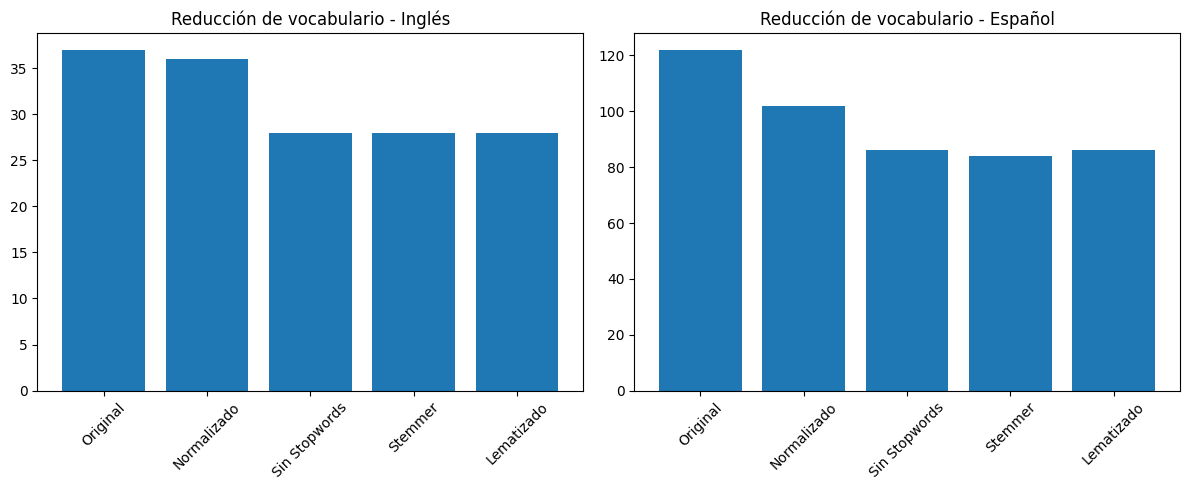

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

ax[0].bar(
    resultados_en.keys(),
    resultados_en.values()
)
ax[0].set_title("Reducción de vocabulario - Inglés")
ax[0].tick_params(axis='x', rotation=45)

ax[1].bar(
    resultados_es.keys(),
    resultados_es.values()
)
ax[1].set_title("Reducción de vocabulario - Español")
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()